In [1]:
%%capture
!pip install indiafactorlibrary

In [2]:
# Notebook: 03a_factor_models
# Series:   pyIndiaFactorInvesting
# Data:     Invespar Indian Factor Library + Nifty sample (Jan 2015 – Dec 2020)
# Run in:   Colab / Binder / local
# Author:   Rajan Raju

# Factor Models in Action

Notebook 03 built the regression toolkit — α, β, R², t-statistics, HAC standard errors, and VIF. This notebook applies that toolkit systematically: one complete FF6 walkthrough on the Nifty SmallCap 250 index, a cross-index summary table for all nine Nifty style indices, rolling regressions showing how factor exposures evolve over time, and four interpretation pitfalls that practitioners commonly encounter.

**What you will leave with**
- A complete CAPM → FF4 → FF6 walkthrough on a new index (SmallCap 250)
- A cross-index summary: FF6 applied to all nine Nifty style indices in one compact table
- Rolling regressions revealing time-varying factor exposures over the 2017–2020 window
- Four common interpretation pitfalls and how to avoid them

**Prerequisites:** Notebook 03 (Introduction to Asset Pricing)

In [3]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

sys.path.insert(0, str(Path('.').resolve().parent))

import indiafactorlibrary as ifl
from src.data import load_nifty_sample

In [4]:
# ── ifl user-agent setup ─────────────────────────────────────────────────────
_lib = ifl.IndiaFactorLibrary()
_lib.session.headers.update({
    'User-Agent': (
        'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
})

def read(name):
    return _lib.read(name)

# ── factor data ──────────────────────────────────────────────────────────────
ff6_raw = read('FF6')[0]
ff6_raw.index = pd.to_datetime(ff6_raw.index)
ff6_full = ff6_raw / 100   # percent → decimal

# ── nifty style indices ──────────────────────────────────────────────────────
nifty_raw = load_nifty_sample()   # already decimal, 2015-01 to 2020-12

# ── align to common period ───────────────────────────────────────────────────
common_start = max(ff6_full.index.min(), nifty_raw.index.min())
common_end   = min(ff6_full.index.max(), nifty_raw.index.max())

ff6_aligned   = ff6_full.loc[common_start:common_end]
nifty_aligned = nifty_raw.loc[common_start:common_end]

factor_cols = ['MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML']
nifty_cols  = nifty_aligned.columns.tolist()

print(f"FF6 columns    : {ff6_aligned.columns.tolist()}")
print(f"Nifty columns  : {nifty_cols}")
print(f"Aligned period : {common_start.strftime('%b %Y')} – {common_end.strftime('%b %Y')}  ({len(ff6_aligned)} months)")

FF6 columns    : ['MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML', 'RF', 'MKT']
Nifty columns  : ['nifty100', 'nifty_midcap150', 'nifty_smallcap250', 'nifty500_value50', 'nifty100_quality30', 'nifty_midcap150_quality50', 'nifty_smallcap250_quality50', 'nifty200_momentum30', 'nifty_midcap150_momentum50']
Aligned period : Jan 2015 – Dec 2020  (72 months)


## 1  Factor Models in Action: SmallCap 250 Walkthrough

### 1a  Index Context and Expected Exposures

The Nifty SmallCap 250 index covers the 251st to 500th largest stocks by market capitalisation listed on the NSE. Conceptually, small-cap stocks carry several a priori expectations:

- **Size (SMB5):** a positive loading is expected — by construction, the index tilts toward smaller firms, which load positively on the size factor
- **Market (MF):** small caps tend to amplify market moves, so a β above 1 would not be surprising
- **Value and quality:** less clear a priori — small caps may be cheap (positive HML) or financially weaker (negative RMW), depending on the period and constituent composition
- **Momentum (WML):** uncertain — the index is not a momentum strategy, so WML may be close to zero

The regression below tests these expectations against the data.

In [5]:
# ── SmallCap 250 excess return ────────────────────────────────────────────────
reg_sc = pd.DataFrame({
    'SC250_xs': nifty_aligned['nifty_smallcap250'] - ff6_aligned['RF'],
    'MF':       ff6_aligned['MF'],
    'SMB5':     ff6_aligned['SMB5'],
    'HML':      ff6_aligned['HML'],
    'RMW':      ff6_aligned['RMW'],
    'CMA':      ff6_aligned['CMA'],
    'WML':      ff6_aligned['WML'],
}).dropna()

hac_kwds = {'cov_type': 'HAC', 'cov_kwds': {'maxlags': 3}}

capm_sc = smf.ols('SC250_xs ~ MF',                                 data=reg_sc).fit(**hac_kwds)
ff4_sc  = smf.ols('SC250_xs ~ MF + SMB5 + HML + WML',              data=reg_sc).fit(**hac_kwds)
ff6_sc  = smf.ols('SC250_xs ~ MF + SMB5 + HML + RMW + CMA + WML', data=reg_sc).fit(**hac_kwds)

table = summary_col(
    [capm_sc, ff4_sc, ff6_sc],
    model_names=['CAPM', 'FF4', 'FF6'],
    stars=True,
    info_dict={'R²': lambda m: f"{m.rsquared:.3f}",
               'Obs': lambda m: f"{int(m.nobs)}"},
)
print(table)
print(f"\nPeriod: {reg_sc.index.min().strftime('%b %Y')} – {reg_sc.index.max().strftime('%b %Y')}  ({len(reg_sc)} months)")
print("Standard errors: HAC (Newey-West, maxlags=3)")


                  CAPM      FF4       FF6   
--------------------------------------------
CMA                                0.0027   
                                   (0.0682) 
HML                      -0.0103   -0.0601  
                         (0.0497)  (0.0751) 
Intercept      -0.0020   -0.0006   -0.0000  
               (0.0031)  (0.0013)  (0.0014) 
MF             1.3478*** 1.0953*** 1.0974***
               (0.0381)  (0.0267)  (0.0303) 
R-squared      0.8808    0.9833    0.9836   
R-squared Adj. 0.8791    0.9823    0.9821   
RMW                                -0.1051  
                                   (0.1019) 
SMB5                     0.7987*** 0.8083***
                         (0.0473)  (0.0507) 
WML                      0.0497    0.0527*  
                         (0.0322)  (0.0319) 
R²             0.881     0.983     0.984    
Obs            72        72        72       
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01

Period: Jan 2015 – Dec 2020  (72 months

### 1c  Reading the Table

The table above shows three columns — CAPM, FF4, FF6 — and a set of rows for each coefficient. Work through it systematically:

- **Intercept (α):** check the CAPM column first. Is it distinguishable from zero? Compare to the FF4 and FF6 columns: does α shrink as factors are added? A substantial shrinkage suggests the apparent alpha was factor exposure all along.
- **MF (market β):** across all three models, check whether SmallCap 250 amplifies or dampens market moves relative to unity.
- **SMB5 (size β):** check whether this is positive and significant in FF4 and FF6 — this is the expected direction for a small-cap index. The table above shows the current period result; check whether it confirms the a priori expectation stated in Section 1a.
- **Significance conventions:** stars use HAC p-values (all standard errors are Newey-West corrected). Single star (*) = p < 0.10; double (**) = p < 0.05; triple (***) = p < 0.01.

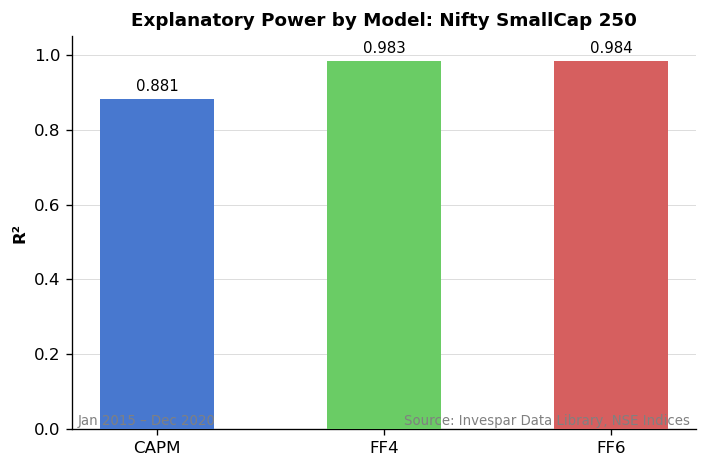

In [6]:
# ── R² bar chart: CAPM → FF4 → FF6 on SmallCap 250 ──────────────────────────
models      = [capm_sc, ff4_sc, ff6_sc]
model_names = ['CAPM', 'FF4', 'FF6']
r2_vals     = [m.rsquared for m in models]

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
bars = ax.bar(model_names, r2_vals, color=['#4878cf', '#6acc65', '#d65f5f'],
              width=0.5, zorder=3)
ax.bar_label(bars, labels=[f'{v:.3f}' for v in r2_vals], padding=3, fontsize=9)

ax.set_ylim(0, 1.05)
ax.set_ylabel('R²', fontsize=10, fontweight='bold')
ax.set_title('Explanatory Power by Model: Nifty SmallCap 250',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

period_str = f"{reg_sc.index.min().strftime('%b %Y')} – {reg_sc.index.max().strftime('%b %Y')}"
ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
ax.annotate('Source: Invespar Data Library, NSE Indices',
            xy=(0.99, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey', ha='right')

plt.tight_layout()
plt.show()

### 1e  R² Interpretation

The bar chart shows how explanatory power builds as factors are added. Typically, the market factor (MF) accounts for a large share of small-cap return variance — all equity indices move with the market. The incremental gain from adding SMB5 in FF4 reflects the size dimension that CAPM misses. Whether the remaining quality and investment factors (RMW, CMA) add meaningfully depends on the composition of the index in this specific period.

Compare this pattern to the Momentum30 result in notebook 03: there, WML delivered the dominant R² jump because Momentum30 is explicitly a momentum strategy. For SmallCap 250, SMB5 is the likely key incremental factor — just as WML did for Momentum30 — but check the chart above to confirm how the gains are distributed across the three models.

## 2  Cross-Index Summary: FF6 on All Nine Nifty Indices

### 2a  Motivation

Running FF6 on a single index is informative but potentially unrepresentative. This section applies the same model to all nine Nifty style indices and presents the results in a compact table, allowing comparison across the full index universe in a single view.

**What to scan for in the table:**
- The **SMB5 column**: which indices load positively (small tilt) vs negatively (large tilt) vs close to zero?
- The **WML column**: momentum-focused indices should show the strongest positive WML loading; non-momentum indices should be near zero
- The **α column**: are any intercepts statistically significant after controlling for all six factors?
- The **R² column**: how much of each index's monthly return variance is explained by the six-factor model?

All regressions use HAC (Newey-West, maxlags=3) standard errors throughout.

In [7]:
# ── Significance helper ───────────────────────────────────────────────────────
def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

# ── FF6 runner: one index at a time ──────────────────────────────────────────
def run_ff6(col):
    """Run FF6 with HAC on one Nifty index; return dict of key statistics."""
    xs = nifty_aligned[col] - ff6_aligned['RF']
    df = pd.DataFrame(
        {'y': xs, **{f: ff6_aligned[f] for f in factor_cols}}
    ).dropna()
    m = smf.ols('y ~ MF + SMB5 + HML + RMW + CMA + WML', data=df).fit(
        cov_type='HAC', cov_kwds={'maxlags': 3}
    )
    return {
        'col':   col,
        'alpha':  m.params['Intercept'],  'alpha_p':  m.pvalues['Intercept'],
        'MF':     m.params['MF'],          'MF_p':     m.pvalues['MF'],
        'SMB5':   m.params['SMB5'],        'SMB5_p':   m.pvalues['SMB5'],
        'HML':    m.params['HML'],         'HML_p':    m.pvalues['HML'],
        'RMW':    m.params['RMW'],         'RMW_p':    m.pvalues['RMW'],
        'CMA':    m.params['CMA'],         'CMA_p':    m.pvalues['CMA'],
        'WML':    m.params['WML'],         'WML_p':    m.pvalues['WML'],
        'R2':     m.rsquared,
    }

# ── Loop over all nine indices ────────────────────────────────────────────────
raw_results = [run_ff6(col) for col in nifty_cols]
print(f"Computed FF6 results for {len(raw_results)} indices.")

Computed FF6 results for 9 indices.


In [8]:
# ── Short display names ───────────────────────────────────────────────────────
nifty_display = {
    'nifty100':                     'Nifty 100',
    'nifty_midcap150':              'MidCap 150',
    'nifty_smallcap250':            'SmallCap 250',
    'nifty500_value50':             'Value 50',
    'nifty100_quality30':           'Quality 30',
    'nifty_midcap150_quality50':    'MidCap Quality 50',
    'nifty_smallcap250_quality50':  'SmallCap Quality 50',
    'nifty200_momentum30':          'Momentum 30',
    'nifty_midcap150_momentum50':   'MidCap Momentum 50',
}

# ── Format into display DataFrame ────────────────────────────────────────────
rows = []
for r in raw_results:
    rows.append({
        'Index':  nifty_display.get(r['col'], r['col']),
        'α':      f"{r['alpha']:+.4f}{stars(r['alpha_p'])}",
        'β_MF':   f"{r['MF']:+.3f}{stars(r['MF_p'])}",
        'β_SMB5': f"{r['SMB5']:+.3f}{stars(r['SMB5_p'])}",
        'β_HML':  f"{r['HML']:+.3f}{stars(r['HML_p'])}",
        'β_RMW':  f"{r['RMW']:+.3f}{stars(r['RMW_p'])}",
        'β_CMA':  f"{r['CMA']:+.3f}{stars(r['CMA_p'])}",
        'β_WML':  f"{r['WML']:+.3f}{stars(r['WML_p'])}",
        'R²':     f"{r['R2']:.3f}",
    })

df_summary = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print(df_summary.to_string(index=False))
print(f"\nPeriod: {common_start.strftime('%b %Y')} – {common_end.strftime('%b %Y')}  ({len(nifty_aligned)} months)")
print("Standard errors: HAC (Newey-West, maxlags=3)")
print("Significance: * p<0.10  ** p<0.05  *** p<0.01  (α is monthly, not annualised)")

              Index          α      β_MF    β_SMB5     β_HML    β_RMW     β_CMA     β_WML    R²
          Nifty 100    -0.0007 +1.019*** -0.250***  +0.096** +0.140**  -0.122**    -0.037 0.985
         MidCap 150 +0.0042*** +1.050*** +0.454***  -0.183**   -0.162    -0.030    -0.039 0.963
       SmallCap 250    -0.0000 +1.097*** +0.808***    -0.060   -0.105    +0.003   +0.053* 0.984
           Value 50   -0.0049* +1.062***    +0.101 +0.610***  +0.327* +0.499*** -0.306*** 0.917
         Quality 30    -0.0001 +0.989*** -0.139*** -0.290***  +0.224*    -0.016    -0.032 0.936
  MidCap Quality 50 +0.0060*** +0.929*** +0.342*** -0.364***   -0.170    -0.107    -0.045 0.922
SmallCap Quality 50    +0.0020 +0.946*** +0.732***    -0.027   +0.072    -0.133    +0.072 0.955
        Momentum 30    -0.0001 +1.015***    -0.056    +0.080   +0.177    +0.053 +0.357*** 0.904
 MidCap Momentum 50   +0.0045* +1.039*** +0.401***  -0.294**   -0.189    -0.060 +0.207*** 0.904

Period: Jan 2015 – Dec 2020  (72 months

### 2c  Reading the Cross-Index Table

The table above has one row per index and one column per factor exposure plus R². Scan it as follows:

- **α column:** the monthly intercept after controlling for all six factors. A starred value suggests return variation that the full factor model does not explain. Most well-constructed style indices are definitions of factor exposure, not attempts to generate unexplained return, so most αs should be close to zero.
- **β_SMB5 column:** look for a gradient from large-cap to small-cap indices. Large-cap indices should load negatively or near zero on SMB5; small-cap indices should load positively. Whether this gradient is steep or gradual is visible in the table.
- **β_WML column:** momentum-focused indices (Momentum 30, MidCap Momentum 50) should show the strongest positive WML exposure. Other indices may be close to zero or slightly negative.
- **R² column:** a proxy for how well FF6 spans each index's return variation. Indices with mixed or ambiguous factor content tend to show lower R².

Note that the table reflects the Jan 2015–Dec 2020 period only. Signs and magnitudes may differ over longer or different windows.

## 3  Rolling Regressions: Time-Varying Exposures

### 3a  Motivation

The regressions in Sections 1 and 2 produce a single set of coefficients estimated over the full 72-month sample. This assumes a static relationship: the same β for every month from Jan 2015 to Dec 2020. That assumption is convenient but rarely accurate in practice. Factor exposures change as:

- **Index reconstitution** alters the constituent mix (most Nifty style indices rebalance annually)
- **Market regimes shift** — the factor that drives returns in a sustained bull market may differ from a crisis or recovery period
- **The factor premium varies through the cycle** — momentum, in particular, is known to crash after extended runs

A rolling regression re-estimates the model using only the most recent *w* months, producing a time series of coefficients that reveals how exposures evolve. Here we use a 36-month window and focus on two contrasting indices:

- **SmallCap 250:** expected to show a persistently positive SMB5 loading, with possible variation around market dislocations
- **Momentum30:** expected to show a positive WML loading that may shift during momentum crashes

*Note: rolling windows use standard OLS (not HAC). With only 36 observations per window, HAC corrections introduce more instability than they remove. This is standard practice for rolling-window analysis.*

In [9]:
# ── Local rolling regression (36-month window, standard OLS) ─────────────────
# src/factors.rolling_regression has a statsmodels version incompatibility;
# this local implementation is equivalent and uses only stable SM APIs.
def _rolling_regression(returns_series, factor_df, window=36):
    """Rolling OLS; returns DataFrame with columns: const, <factors>, R_squared."""
    common = returns_series.index.intersection(factor_df.index)
    y = returns_series.loc[common]
    # Build X with intercept manually (avoids add_constant kwarg differences)
    X = pd.concat(
        [pd.Series(1.0, index=y.index, name='const'), factor_df.loc[common]],
        axis=1,
    )
    results = {}
    for end_pos in range(window, len(y) + 1):
        y_win = y.iloc[end_pos - window: end_pos]
        X_win = X.iloc[end_pos - window: end_pos]
        try:
            fit = sm.OLS(y_win, X_win).fit()
            row = dict(zip(X.columns, fit.params))
            row['R_squared'] = fit.rsquared
        except Exception:
            row = {c: np.nan for c in list(X.columns) + ['R_squared']}
        results[y.index[end_pos - 1]] = row
    result_df = pd.DataFrame(results).T
    result_df.index.name = 'Date'
    return result_df

# ── Excess returns for rolling windows ───────────────────────────────────────
sc250_xs_roll = (nifty_aligned['nifty_smallcap250']  - ff6_aligned['RF']).dropna()
mom30_xs_roll = (nifty_aligned['nifty200_momentum30'] - ff6_aligned['RF']).dropna()

# ── Run rolling FF6 (36-month window) ────────────────────────────────────────
roll_sc  = _rolling_regression(sc250_xs_roll,  ff6_aligned[factor_cols], window=36)
roll_mom = _rolling_regression(mom30_xs_roll,  ff6_aligned[factor_cols], window=36)

print(f"Rolling window : 36 months")
print(f"SmallCap 250   : {roll_sc.index.min().strftime('%b %Y')} – {roll_sc.index.max().strftime('%b %Y')}  ({len(roll_sc)} points)")
print(f"Momentum30     : {roll_mom.index.min().strftime('%b %Y')} – {roll_mom.index.max().strftime('%b %Y')}  ({len(roll_mom)} points)")
print(f"Columns        : {roll_sc.columns.tolist()}")

Rolling window : 36 months
SmallCap 250   : Dec 2017 – Dec 2020  (37 points)
Momentum30     : Dec 2017 – Dec 2020  (37 points)
Columns        : ['const', 'MF', 'SMB5', 'HML', 'RMW', 'CMA', 'WML', 'R_squared']


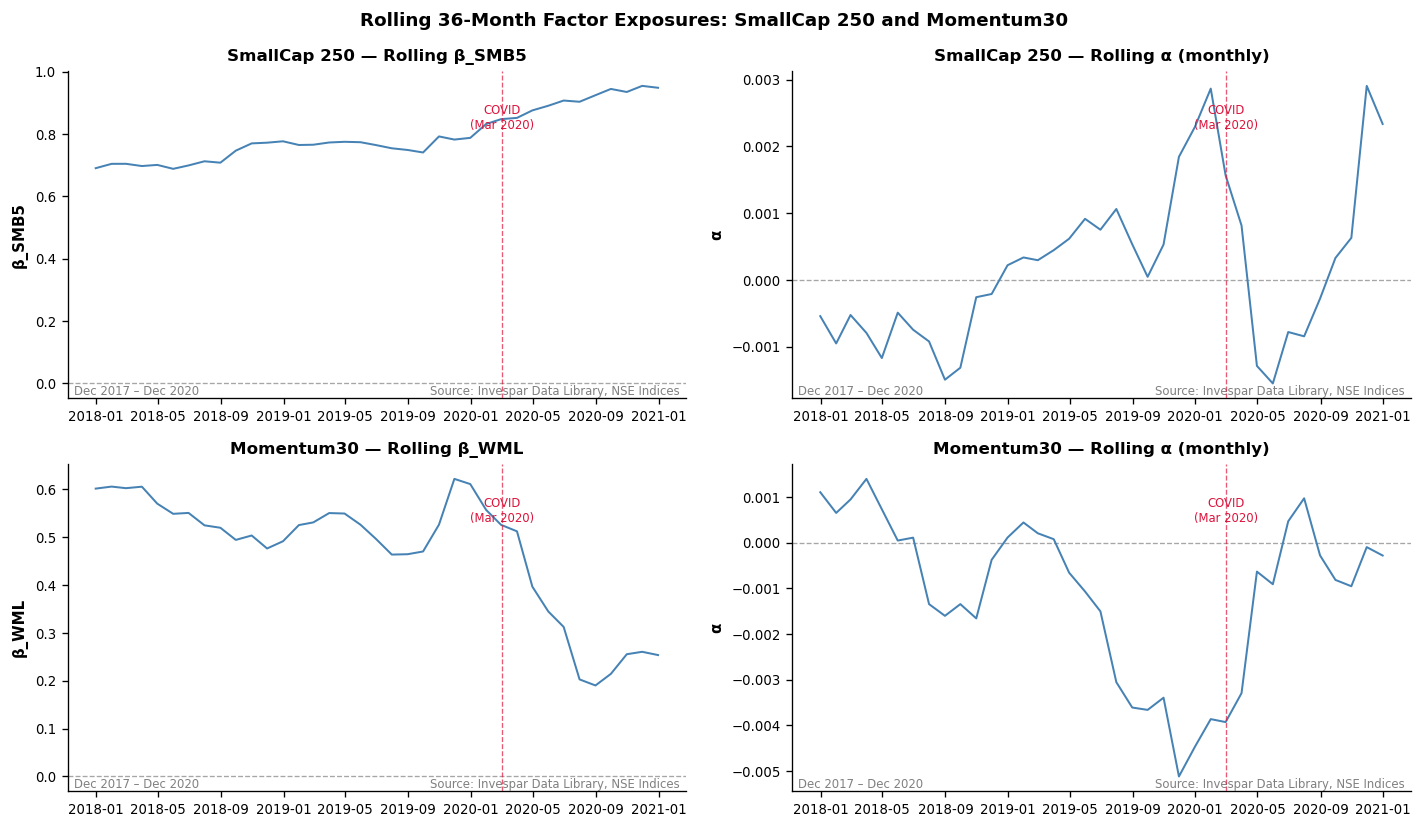

In [10]:
# ── 2×2 rolling chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7), dpi=120)

covid_date = pd.Timestamp('2020-03-01')
source_str = 'Source: Invespar Data Library, NSE Indices'

panels = [
    (axes[0, 0], roll_sc,  'SMB5',  'SmallCap 250 — Rolling β_SMB5',       'β_SMB5'),
    (axes[0, 1], roll_sc,  'const', 'SmallCap 250 — Rolling α (monthly)',  'α'),
    (axes[1, 0], roll_mom, 'WML',   'Momentum30 — Rolling β_WML',          'β_WML'),
    (axes[1, 1], roll_mom, 'const', 'Momentum30 — Rolling α (monthly)',    'α'),
]

for ax, roll_df, col, title, ylabel in panels:
    series = roll_df[col].dropna()
    period_str = (
        f"{series.index.min().strftime('%b %Y')} – "
        f"{series.index.max().strftime('%b %Y')}"
    )

    ax.plot(series.index, series.values, color='steelblue', linewidth=1.2, zorder=3)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.7, zorder=2)

    # COVID annotation if date falls within rolling window
    if series.index.min() <= covid_date <= series.index.max():
        ax.axvline(covid_date, color='crimson', linewidth=0.8,
                   linestyle='--', alpha=0.7, zorder=4)
        ax.annotate(
            'COVID\n(Mar 2020)',
            xy=(covid_date, 0.90),
            xycoords=('data', 'axes fraction'),
            fontsize=7, color='crimson', ha='center', va='top',
        )

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.annotate(period_str, xy=(0.01, 0.01), xycoords='axes fraction',
                fontsize=7, color='grey')
    ax.annotate(source_str, xy=(0.99, 0.01), xycoords='axes fraction',
                fontsize=7, color='grey', ha='right')

plt.suptitle(
    'Rolling 36-Month Factor Exposures: SmallCap 250 and Momentum30',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 3c  What the Rolling Charts Show

The four panels reveal that factor exposures are not constants — they shift over time even for indices with well-defined mandates.

**Interpreting the panels**
- A stable β_SMB5 for SmallCap 250 would confirm a persistent size tilt. Any variation around that level reflects reconstitution lags, index composition changes, and the time-varying correlation structure of small-cap stocks with the size factor.
- β_WML for Momentum30 reveals whether the momentum tilt is stable or episodic. Momentum strategies are known to experience sharp reversals, which could produce visible dips in β_WML around the COVID disruption.
- The α panels show whether any unexplained return persists on a rolling basis, and when it appears or disappears relative to market events.

**Short-sample caveat — important**
The rolling estimates span approximately 37 points (the exact window is shown on each panel). That window is long enough to capture the COVID-19 disruption of March 2020, but too short to distinguish genuine regime shifts from noise. Each rolling estimate covers only 36 observations; standard errors on each individual estimate are high. The single full-sample β in Sections 1 and 2 is a useful summary statistic, but the rolling charts demonstrate that it masks real time variation. Do not overstate what 37 points can prove: the pattern is suggestive of movement, not evidence of a definitive structural break.

## 4  Four Interpretation Pitfalls

The regressions in this notebook produce numbers — α, β, R², t-statistics. Interpreting those numbers correctly requires awareness of four common pitfalls.

---

### Pitfall 1: Statistical Significance ≠ Economic Significance

A coefficient can be highly statistically significant (t-stat well above 3) but economically trivial. With 72 monthly observations, a monthly α of 0.1 basis points (0.001% per month, roughly 1 basis point per year) could be precisely estimated and statistically significant — but irrelevant to any investment decision once transaction costs, taxes, and implementation slippage are considered.

Conversely, an α that is not statistically significant is not necessarily zero. It may simply be imprecisely estimated due to high residual variance or a short sample. The correct interpretation is: “the data are consistent with α = 0, but also consistent with α anywhere in the confidence interval.”

**Rule:** always report both the coefficient magnitude and the confidence interval, not just the star count. Ask: is the economic magnitude large enough to matter given realistic implementation costs, and is the estimate precise enough to trust given the sample length?

### Pitfall 2: Alpha ≠ Skill

A statistically significant positive α tells you the return is not explained by the six factors in the model. It does not tell you *why*. Possible explanations include:

- **Genuine skill:** the manager or index construction adds value beyond systematic factor exposures
- **Omitted factor:** the model is missing a relevant risk factor (e.g., liquidity, idiosyncratic volatility); what appears as alpha is compensation for a risk not captured by FF6
- **Data snooping:** the index was constructed using rules that happened to work in the estimation sample; out-of-sample, the alpha may not persist
- **Structural feature:** rebalancing rules may generate mechanical return contributions (momentum, mean-reversion) not fully captured by WML or HML

Claiming skill from a positive α requires ruling out omitted factors and data-snooping — a high bar that the Harvey, Liu and Zhu (2016) threshold of |t| > 3 is designed to raise.

---

### Pitfall 3: Short Sample Bias

All regressions in this series use Jan 2015–Dec 2020 (72 months). This period includes one major disruption (COVID-19, March 2020) but misses the 2008 Global Financial Crisis, the 2013 taper tantrum, and the 2018 IL&FS liquidity shock in India. A β or α estimated over 72 months may not be representative of behaviour over a full market cycle (typically 5–10 years). The rolling charts in Section 3, spanning approximately 37 months, amplify this concern further: each panel captures only one end-of-cycle stress event, not the full range of market conditions.

### Pitfall 4: High R² ≠ Model Validation

A high R² means the factors explain a large fraction of the return variance *in the sample used to estimate the model*. It does not mean:

- The model is correctly specified (including irrelevant but correlated regressors can inflate R²)
- The exposures will persist out of sample (the rolling charts in Section 3 show they shift)
- The model captures causation (factors may be correlated proxies, not structural drivers)
- The intercept (α) is zero — a high R² is fully compatible with any level of α

R² is a measure of in-sample fit, not of model correctness or predictive power. The appropriate question is not “is R² high?” but “does each included factor have a plausible economic rationale, is the residual small, and does the residual appear structureless (no heteroscedasticity, no autocorrelation)?”

**Summary:** treat the regression output as a structured description of past return variation, not as a predictive model of future behaviour. The toolkit built in notebooks 03 and 03a is powerful when used carefully — and systematically misleads when results are over-interpreted.

## 5  What We Established

| Topic | Key Point |
|-------|-----------|
| Full walkthrough (SmallCap 250) | CAPM → FF4 → FF6 with HAC standard errors; SMB5 is the expected dominant factor for a small-cap index |
| Cross-index summary | FF6 on all nine Nifty indices in one table; size, momentum, and quality gradients visible across the index universe |
| Rolling regressions | Factor exposures shift over the ~37-month rolling window (Dec 2017–Dec 2020); COVID disruption visible; short span limits inference |
| Interpretation pitfalls | Statistical ≠ economic significance; α ≠ skill; short sample limits inference; R² ≠ validation |

---
**Next:** `04_momentum_deep_dive.ipynb` — a detailed decomposition of the Nifty momentum indices, momentum crashes, and how WML interacts with market and size exposures across sub-periods.

## References

Carhart, M.M. (1997). On Persistence in Mutual Fund Performance. *Journal of Finance*, 52(1), 57–82.

Fama, E.F. and French, K.R. (1993). Common Risk Factors in the Returns on Stocks and Bonds. *Journal of Financial Economics*, 33(1), 3–56.

Fama, E.F. and French, K.R. (2015). A Five-Factor Asset Pricing Model. *Journal of Financial Economics*, 116(1), 1–22.

Fama, E.F. and French, K.R. (2018). Choosing Factors. *Journal of Financial Economics*, 128(2), 234–252.

Harvey, C.R., Liu, Y., and Zhu, H. (2016). …and the Cross-Section of Expected Returns. *Review of Financial Studies*, 29(1), 5–68.

Newey, W.K. and West, K.D. (1987). A Simple, Positive Semi-Definite, Heteroscedasticity and Autocorrelation Consistent Covariance Matrix. *Econometrica*, 55(3), 703–708.

Raju, R. (2022). Four and Five-Factor Models in the Indian Equities Market. Available at SSRN: https://ssrn.com/abstract=4054146.

Invespar Indian Factor Library. Data source for all factor return series used in this notebook. https://invespar.com/research/